Dataset:
    Temperature  Humidity  WindSpeed  Outlook  Weather
0            30        70         10        2        2
1            25        80          8        1        0
2            20        85         12        0        0
3            18        90          5        0        0
4            35        50         15        2        2
5            32        60         18        2        2
6            22        88          7        0        0
7            28        65         11        2        2
8            24        82          6        1        0
9            27        75          9        1        1
10           31        55         20        2        2
11           19        92          4        0        0
12           21        87          8        0        0
13           34        48         17        2        2
14           26        78          7        1        1
15           23        84         10        1        0
16           29        62         13        2        2
1

/home/ip/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


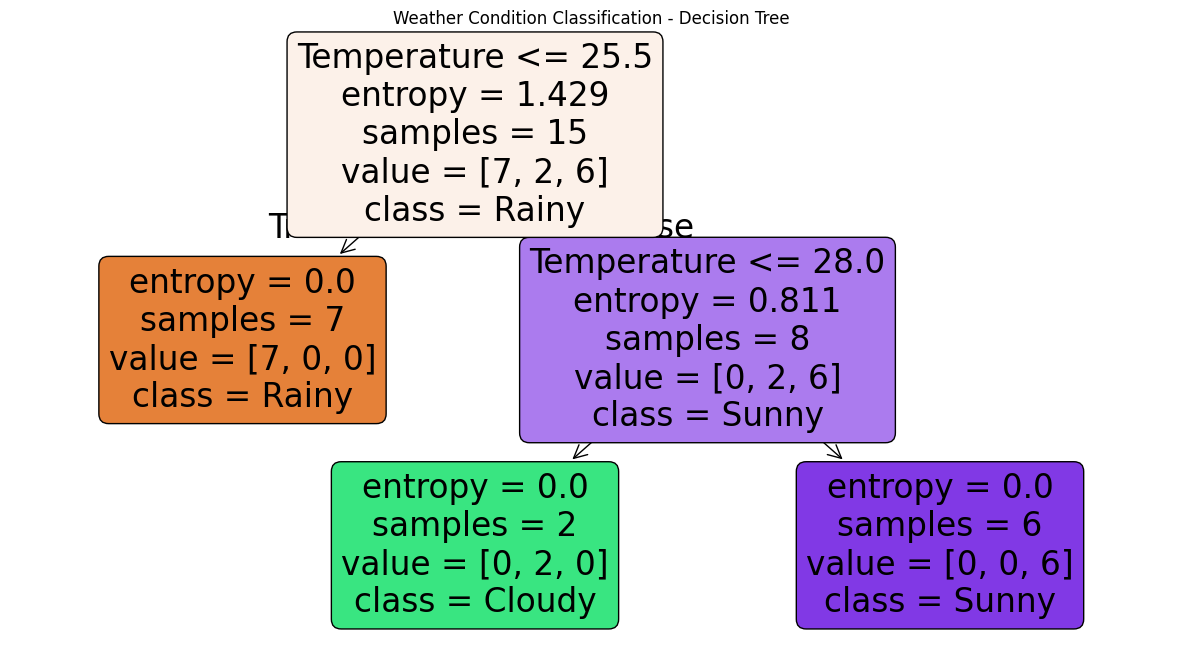

In [1]:
# Weather Condition Classification using Decision Tree

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# -----------------------------
# 1. Create sample dataset
# -----------------------------
data = {
    'Temperature': [30, 25, 20, 18, 35, 32, 22, 28, 24, 27,
                    31, 19, 21, 34, 26, 23, 29, 17, 33, 20],
    'Humidity': [70, 80, 85, 90, 50, 60, 88, 65, 82, 75,
                 55, 92, 87, 48, 78, 84, 62, 95, 52, 89],
    'WindSpeed': [10, 8, 12, 5, 15, 18, 7, 11, 6, 9,
                  20, 4, 8, 17, 7, 10, 13, 3, 16, 6],
    'Outlook': [2, 1, 0, 0, 2, 2, 0, 2, 1, 1,
                2, 0, 0, 2, 1, 1, 2, 0, 2, 0],

    # Target: 0 = Rainy, 1 = Cloudy, 2 = Sunny
    'Weather': [2, 0, 0, 0, 2, 2, 0, 2, 0, 1,
                2, 0, 0, 2, 1, 0, 2, 0, 2, 0]
}

df = pd.DataFrame(data)

print("Dataset:")
print(df)

# -----------------------------
# 2. Separate features and target
# -----------------------------
X = df[['Temperature', 'Humidity', 'WindSpeed', 'Outlook']]
y = df['Weather']

# -----------------------------
# 3. Split dataset
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# -----------------------------
# 4. Create Decision Tree
# -----------------------------
model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=4,
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

# -----------------------------
# 5. Make predictions
# -----------------------------
y_pred = model.predict(X_test)

# -----------------------------
# 6. Evaluate the model
# -----------------------------
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=['Rainy', 'Cloudy', 'Sunny'],
    zero_division=0
))

# -----------------------------
# 7. Predict new weather
# -----------------------------
new_weather = [[28, 65, 10, 2]]

prediction = model.predict(new_weather)

weather_names = {
    0: 'Rainy',
    1: 'Cloudy',
    2: 'Sunny'
}

print("\nNew Weather Data:")
print("Temperature = 28°C")
print("Humidity = 65%")
print("Wind Speed = 10 km/h")
print("Outlook = Sunny")

print("\nPredicted Weather Condition:",
      weather_names[prediction[0]])

# -----------------------------
# 8. Visualize Decision Tree
# -----------------------------
plt.figure(figsize=(15, 8))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=['Rainy', 'Cloudy', 'Sunny'],
    filled=True,
    rounded=True
)

plt.title("Weather Condition Classification - Decision Tree")
plt.show()
